# Comparacion de modelos para Sprint 3

En este notebook comparamos varios modelos de clasificacion usando el mismo split temporal del proyecto. El objetivo es identificar que alternativa ofrece el mejor desempeno antes de pasar a la etapa de optimizacion de hiperparametros.

Modelos incluidos:
- Logistic Regression
- Decision Tree
- Random Forest
- SVM lineal calibrado
- Extra Trees
- XGBoost
- LightGBM
- CatBoost


## Criterio de comparacion

Para mantener una comparacion consistente, todos los modelos se entrenan con las mismas variables seleccionadas y se validan sobre el mismo corte temporal. Primero revisamos `ROC-AUC` como metrica general de ranking y luego contrastamos `PR-AUC`, `precision`, `recall` y `f1` para entender mejor el comportamiento sobre la clase premium.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')


In [2]:
TARGET_COLUMN = 'is_premium'
ID_COLUMN = 'customer_unique_id'
VALIDATION_CUTOFF = '2018-07-01'

project_root = Path.cwd().resolve()
if not (project_root / 'data').exists():
    for candidate in [project_root, *project_root.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            project_root = candidate
            break

features_path = project_root / 'data' / 'processed' / '06_features_selected.parquet'
source_path = project_root / 'data' / 'processed' / '05_features_rfm.parquet'

selected_df = pd.read_parquet(features_path)
source_df = pd.read_parquet(source_path, columns=[ID_COLUMN, 'last_purchase']).copy()
df = selected_df.merge(source_df, on=ID_COLUMN, how='left', validate='one_to_one')

cutoff = pd.Timestamp(VALIDATION_CUTOFF)
train_df = df[df['last_purchase'] < cutoff].copy()
val_df = df[df['last_purchase'] >= cutoff].copy()

features = [col for col in selected_df.columns if col not in {ID_COLUMN, TARGET_COLUMN}]
categorical_features = train_df[features].select_dtypes(include=['object', 'string', 'category']).columns.tolist()
numeric_features = [col for col in features if col not in categorical_features]

positives = max(1, int(train_df[TARGET_COLUMN].sum()))
negatives = max(1, int(len(train_df) - positives))
scale_pos_weight = negatives / positives

display(pd.DataFrame({
    'split': ['train', 'validation'],
    'rows': [len(train_df), len(val_df)],
    'positive_rate': [train_df[TARGET_COLUMN].mean(), val_df[TARGET_COLUMN].mean()],
}))

print(f'Features usadas: {len(features)}')
print(f'Numericas: {len(numeric_features)} | Categoricas: {len(categorical_features)}')
print(f'scale_pos_weight: {scale_pos_weight:.4f}')

,split,rows,positive_rate
0,train,83589,0.212923
1,validation,6230,0.228250


Features usadas: 28
Numericas: 23 | Categoricas: 5
scale_pos_weight: 3.6965


In [3]:
def build_preprocessor(scale_numeric: bool) -> ColumnTransformer:
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))

    categorical_steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ]

    return ColumnTransformer(
        transformers=[
            ('num', Pipeline(numeric_steps), numeric_features),
            ('cat', Pipeline(categorical_steps), categorical_features),
        ]
    )

def build_model_catalog() -> dict[str, tuple[object, bool]]:
    return {
        'logistic_regression': (
            LogisticRegression(class_weight='balanced', max_iter=1500, random_state=42),
            True,
        ),
        'decision_tree': (
            DecisionTreeClassifier(class_weight='balanced', max_depth=10, min_samples_leaf=10, random_state=42),
            False,
        ),
        'random_forest': (
            RandomForestClassifier(
                n_estimators=160,
                random_state=42,
                n_jobs=-1,
                class_weight='balanced_subsample',
                min_samples_leaf=5,
                max_depth=12,
            ),
            False,
        ),
        'svm_linear': (
            CalibratedClassifierCV(
                estimator=LinearSVC(class_weight='balanced', C=1.0, random_state=42, max_iter=3000),
                cv=3,
            ),
            True,
        ),
        'extra_trees': (
            ExtraTreesClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1,
                class_weight='balanced',
                min_samples_leaf=3,
                max_depth=14,
            ),
            False,
        ),
        'xgboost': (
            XGBClassifier(
                n_estimators=250,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.8,
                min_child_weight=2,
                reg_alpha=0.0,
                reg_lambda=1.0,
                objective='binary:logistic',
                eval_metric='logloss',
                random_state=42,
                n_jobs=-1,
                scale_pos_weight=scale_pos_weight,
            ),
            False,
        ),
        'lightgbm': (
            LGBMClassifier(
                n_estimators=250,
                learning_rate=0.05,
                num_leaves=31,
                subsample=0.9,
                colsample_bytree=0.8,
                random_state=42,
                class_weight='balanced',
                verbosity=-1,
            ),
            False,
        ),
        'catboost': (
            CatBoostClassifier(
                iterations=250,
                depth=6,
                learning_rate=0.05,
                loss_function='Logloss',
                eval_metric='AUC',
                auto_class_weights='Balanced',
                random_seed=42,
                verbose=False,
            ),
            False,
        ),
    }

def build_pipeline(model: object, scale_numeric: bool) -> Pipeline:
    return Pipeline([('preprocessor', build_preprocessor(scale_numeric)), ('model', model)])

def predict_scores(model: Pipeline, features_df: pd.DataFrame) -> pd.Series:
    if hasattr(model, 'predict_proba'):
        return pd.Series(model.predict_proba(features_df)[:, 1], index=features_df.index)
    if hasattr(model, 'decision_function'):
        return pd.Series(model.decision_function(features_df), index=features_df.index)
    raise ValueError('El modelo no soporta predict_proba ni decision_function.')

def evaluate_predictions(y_true: pd.Series, y_scores: pd.Series, threshold: float = 0.5) -> dict[str, float | list[list[int]]]:
    y_pred = (y_scores >= threshold).astype(int)
    roc_auc = float(roc_auc_score(y_true, y_scores))
    return {
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'roc_auc': roc_auc,
        'gini': float((2 * roc_auc) - 1),
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }

In [4]:
results = []
trained_models = {}
validation_scores = {}
validation_targets = val_df[TARGET_COLUMN].copy()

for model_name, (estimator, scale_numeric) in build_model_catalog().items():
    pipeline = build_pipeline(estimator, scale_numeric)
    pipeline.fit(train_df[features], train_df[TARGET_COLUMN])

    train_scores = predict_scores(pipeline, train_df[features])
    val_scores = predict_scores(pipeline, val_df[features])

    trained_models[model_name] = pipeline
    validation_scores[model_name] = val_scores

    train_metrics = evaluate_predictions(train_df[TARGET_COLUMN], train_scores)
    val_metrics = evaluate_predictions(val_df[TARGET_COLUMN], val_scores)
    pr_auc_val = float(average_precision_score(val_df[TARGET_COLUMN], val_scores))

    results.append({
        'model_name': model_name,
        'roc_auc_val': val_metrics['roc_auc'],
        'pr_auc_val': pr_auc_val,
        'gini_val': val_metrics['gini'],
        'precision_val': val_metrics['precision'],
        'recall_val': val_metrics['recall'],
        'f1_val': val_metrics['f1'],
        'roc_auc_train': train_metrics['roc_auc'],
        'gini_train': train_metrics['gini'],
        'confusion_matrix_val': val_metrics['confusion_matrix'],
    })

results_df = pd.DataFrame(results).sort_values(['roc_auc_val', 'pr_auc_val'], ascending=False).reset_index(drop=True)
results_df


/home/gaston/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/gaston/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model_name,roc_auc_val,pr_auc_val,gini_val,precision_val,recall_val,f1_val,roc_auc_train,gini_train,confusion_matrix_val
0,lightgbm,0.802465,0.593492,0.604930,0.476715,0.669480,0.556888,0.840562,0.681123,"[[3763, 1045], [470, 952]]"
1,catboost,0.800338,0.589609,0.600676,0.464320,0.686357,0.553916,0.817748,0.635495,"[[3682, 1126], [446, 976]]"
2,xgboost,0.797788,0.588072,0.595575,0.470930,0.683544,0.557659,0.827226,0.654452,"[[3716, 1092], [450, 972]]"
3,random_forest,0.792918,0.566158,0.585835,0.476571,0.629395,0.542424,0.810736,0.621471,"[[3825, 983], [527, 895]]"
4,logistic_regression,0.788422,0.566182,0.576845,0.452793,0.644163,0.531785,0.804076,0.608152,"[[3701, 1107], [506, 916]]"
5,svm_linear,0.787186,0.562829,0.574371,0.678992,0.284107,0.400595,0.803881,0.607761,"[[4617, 191], [1018, 404]]"
6,decision_tree,0.778397,0.545793,0.556795,0.444900,0.687060,0.540077,0.812901,0.625803,"[[3589, 1219], [445, 977]]"
7,extra_trees,0.770838,0.538878,0.541677,0.442936,0.619550,0.516564,0.792970,0.585941,"[[3700, 1108], [541, 881]]"


In [5]:
best_row = results_df.iloc[0]
display(results_df[['model_name', 'roc_auc_val', 'pr_auc_val', 'gini_val', 'precision_val', 'recall_val', 'f1_val']])

print('Resumen del mejor modelo:')
print(best_row['model_name'])
print(f"ROC-AUC en validacion: {best_row['roc_auc_val']:.4f}")
print(f"PR-AUC en validacion: {best_row['pr_auc_val']:.4f}")
print(f"Matriz de confusion en validacion: {best_row['confusion_matrix_val']}")


,model_name,roc_auc_val,pr_auc_val,gini_val,precision_val,recall_val,f1_val
0,lightgbm,0.802465,0.593492,0.604930,0.476715,0.669480,0.556888
1,catboost,0.800338,0.589609,0.600676,0.464320,0.686357,0.553916
2,xgboost,0.797788,0.588072,0.595575,0.470930,0.683544,0.557659
3,random_forest,0.792918,0.566158,0.585835,0.476571,0.629395,0.542424
4,logistic_regression,0.788422,0.566182,0.576845,0.452793,0.644163,0.531785
5,svm_linear,0.787186,0.562829,0.574371,0.678992,0.284107,0.400595
6,decision_tree,0.778397,0.545793,0.556795,0.444900,0.687060,0.540077
7,extra_trees,0.770838,0.538878,0.541677,0.442936,0.619550,0.516564


Resumen del mejor modelo:
lightgbm
ROC-AUC en validacion: 0.8025
PR-AUC en validacion: 0.5935
Matriz de confusion en validacion: [[3763, 1045], [470, 952]]


## PR-AUC y analisis del threshold

Ademas de `ROC-AUC`, incorporamos `PR-AUC` y revisamos como cambian las metricas al mover el umbral de decision. Con esto buscamos un punto mas equilibrado entre identificar clientes premium y controlar falsos positivos.


In [6]:
top_models = results_df.head(3)['model_name'].tolist()
results_df[results_df['model_name'].isin(top_models)][['model_name', 'roc_auc_val', 'pr_auc_val', 'precision_val', 'recall_val', 'f1_val']]


,model_name,roc_auc_val,pr_auc_val,precision_val,recall_val,f1_val
0,lightgbm,0.802465,0.593492,0.476715,0.669480,0.556888
1,catboost,0.800338,0.589609,0.464320,0.686357,0.553916
2,xgboost,0.797788,0.588072,0.470930,0.683544,0.557659


## Curvas Precision-Recall

En las siguientes graficas observamos como se comportan los tres mejores modelos sobre la clase premium. Una curva mas alta indica que el modelo sostiene mejor el equilibrio entre `precision` y `recall`, y un `PR-AUC` mayor respalda ese comportamiento.


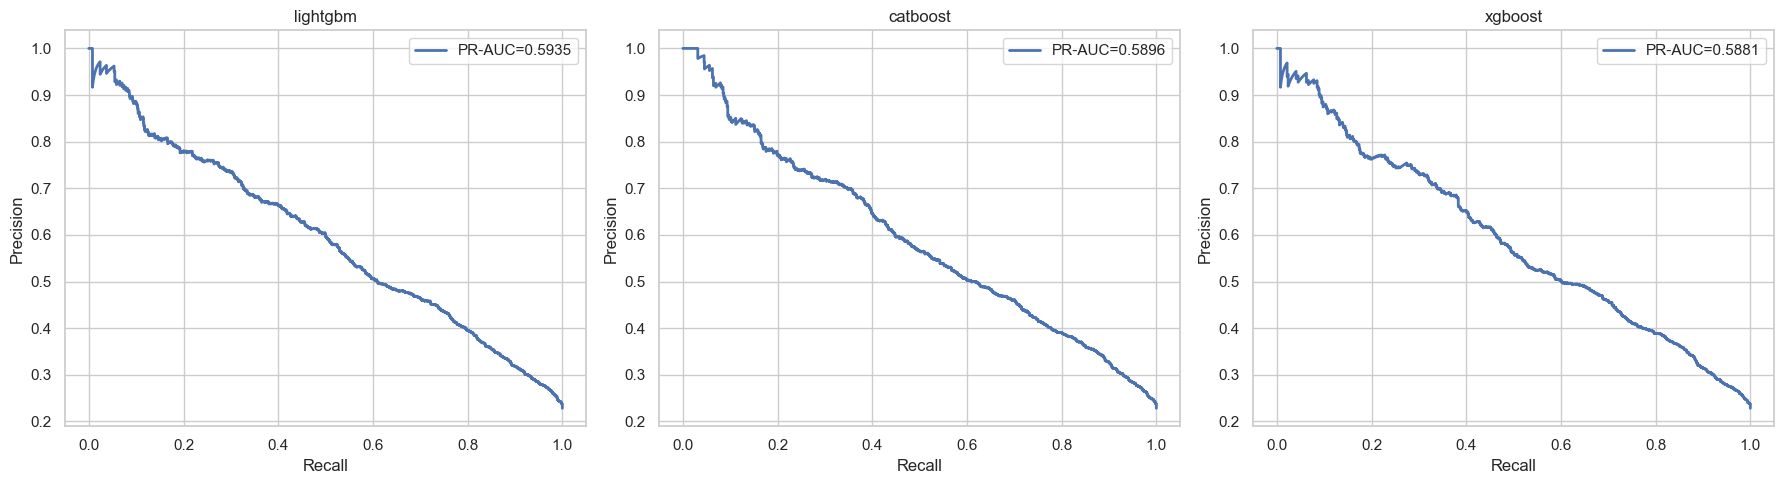

In [7]:
fig, axes = plt.subplots(1, len(top_models), figsize=(6 * len(top_models), 5), squeeze=False)
for ax, model_name in zip(axes[0], top_models):
    y_scores = validation_scores[model_name]
    precision, recall, _ = precision_recall_curve(validation_targets, y_scores)
    pr_auc = average_precision_score(validation_targets, y_scores)
    ax.plot(recall, precision, label=f'PR-AUC={pr_auc:.4f}', linewidth=2)
    ax.set_title(model_name)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend()
plt.tight_layout()
plt.show()


## Metricas por threshold

Aqui analizamos como cambian `precision`, `recall`, `f1` y `specificity` a medida que movemos el umbral de decision. Esto nos ayuda a identificar si conviene operar con un threshold orientado a mayor captura de clientes premium o con un punto mas equilibrado entre errores y aciertos.


In [8]:
def threshold_metrics(y_true: pd.Series, y_scores: pd.Series, thresholds: list[float] | None = None) -> pd.DataFrame:
    if thresholds is None:
        thresholds = [i / 20 for i in range(1, 20)]
    rows = []
    for threshold in thresholds:
        y_pred = (y_scores >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        specificity = tn / (tn + fp) if (tn + fp) else 0.0
        rows.append({
            'threshold': threshold,
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'specificity': specificity,
            'balanced_point_gap': abs(precision_score(y_true, y_pred, zero_division=0) - recall_score(y_true, y_pred, zero_division=0)),
        })
    return pd.DataFrame(rows)

threshold_tables = {model_name: threshold_metrics(validation_targets, validation_scores[model_name]) for model_name in top_models}
best_thresholds = []
for model_name, table in threshold_tables.items():
    best_f1 = table.sort_values('f1', ascending=False).iloc[0]
    best_balance = table.sort_values(['balanced_point_gap', 'f1'], ascending=[True, False]).iloc[0]
    best_thresholds.append({
        'model_name': model_name,
        'best_f1_threshold': best_f1['threshold'],
        'best_f1': best_f1['f1'],
        'precision_at_best_f1': best_f1['precision'],
        'recall_at_best_f1': best_f1['recall'],
        'most_balanced_threshold': best_balance['threshold'],
        'precision_at_balance': best_balance['precision'],
        'recall_at_balance': best_balance['recall'],
        'f1_at_balance': best_balance['f1'],
        'specificity_at_balance': best_balance['specificity'],
    })
pd.DataFrame(best_thresholds).sort_values('best_f1', ascending=False).reset_index(drop=True)


,model_name,best_f1_threshold,best_f1,precision_at_best_f1,recall_at_best_f1,most_balanced_threshold,precision_at_balance,recall_at_balance,f1_at_balance,specificity_at_balance
0,xgboost,0.5,0.557659,0.470930,0.683544,0.6,0.536046,0.528129,0.532058,0.864809
1,lightgbm,0.5,0.556888,0.476715,0.669480,0.6,0.547236,0.549930,0.548579,0.865433
2,catboost,0.5,0.553916,0.464320,0.686357,0.6,0.544940,0.541491,0.543210,0.866265


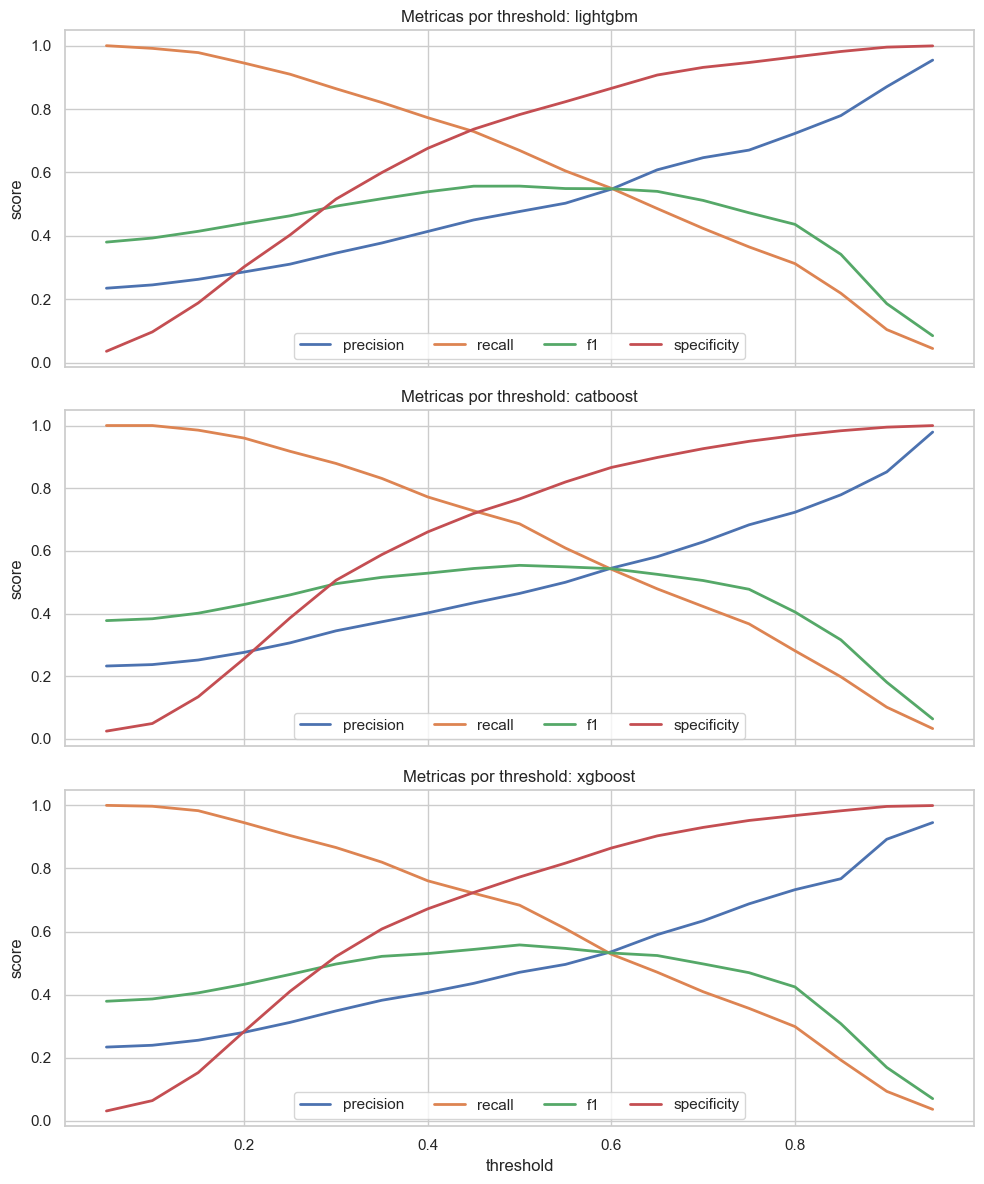

In [9]:
fig, axes = plt.subplots(len(top_models), 1, figsize=(10, 4 * len(top_models)), sharex=True)
if len(top_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, top_models):
    table = threshold_tables[model_name]
    ax.plot(table['threshold'], table['precision'], label='precision', linewidth=2)
    ax.plot(table['threshold'], table['recall'], label='recall', linewidth=2)
    ax.plot(table['threshold'], table['f1'], label='f1', linewidth=2)
    ax.plot(table['threshold'], table['specificity'], label='specificity', linewidth=2)
    ax.set_title(f'Metricas por threshold: {model_name}')
    ax.set_ylabel('score')
    ax.legend(ncol=4, loc='lower center')

axes[-1].set_xlabel('threshold')
plt.tight_layout()
plt.show()


## Conclusiones del equipo

- Para la siguiente fase proponemos trabajar con `LightGBM`.
- Como criterio principal de comparacion vamos a mantener `ROC-AUC`, complementado con `PR-AUC`.
- Elegimos `LightGBM` porque obtuvo el mejor resultado en ambas metricas dentro del conjunto evaluado.
- Como threshold operativo sugerimos iniciar con un valor cercano a `0.60` si buscamos un equilibrio entre `precision` y `recall`.
- Si la prioridad cambia hacia maximizar `F1`, entonces `0.50` sigue siendo una referencia valida con la configuracion actual.

Interpretacion practica:
- Con `0.50` capturamos mas clientes premium, pero tambien aumentan los falsos positivos.
- Con `0.60` el cruce entre `precision` y `recall` se vuelve mas parejo, por lo que ese punto resulta mas defendible como criterio operativo.


## Criterios de lectura

- Primero revisamos `roc_auc_val` para identificar el mejor candidato a optimizar.
- Luego contrastamos `pr_auc_val`, `precision_val` y `recall_val` para validar si el modelo tambien responde bien sobre la clase premium.
- Si las diferencias entre modelos son pequenas, conviene priorizar simplicidad operativa e interpretabilidad.
